# Running Differential Transcription Analysis for ADP

In [2]:
library(data.table)
library(stringr)
# plotting
library(ggplot2)
library(cowplot)
# DE analysis
#library(limma)
library(edgeR)
library(DESeq2)
library(UpSetR)
library(gridExtra)
#library(clusterProfiler)
#library(org.Hs.eg.db)

In [3]:
# save the results and TFEA input
results_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/results/"
tfea_input_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/data/TFEA_input/"

## 1. Get counts

In [4]:
# read in preliminary 5ptrunc counts
# the 
count_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP//data/counts/"
genes_file=paste0(count_dir, "fixed_genes_CUWA_ADP_3.26.25_counts.txt")
gene_counts <- fread(genes_file)
gene_counts[1:2,]

# get easier names
colnames(gene_counts) <- c("Geneid", "Chr", "Start", "End", "Strand", "Length", 
                           "ADP_1", "ADP_2", "Veh_1", "Veh_2")
# get the gene name (not just isoform)
gene_counts$Gene <- str_split_fixed(gene_counts$Geneid, ":", 2)[,1]
nrow(gene_counts)
length(unique(gene_counts$Gene))

# only keep the non-putative Refseq genes
nonput <- fread("/Users/hopekirby/Desktop/TF_Enh_Linking/Final_Project_Repos/Bidir_Counting_Analysis/assets/hg38_refseq_diff53prime_5ptrunc_counting.bed")
nonput$Gene <- str_split_fixed(nonput$V4, ":", 2)[,1]
nrow(nonput)
length(unique(nonput$Gene))
nonput[1:2,]
# look at some of the names that are putative
setdiff(gene_counts$Gene, nonput$Gene)[1:3]
gene_counts <- gene_counts[gene_counts$Gene %in% nonput$Gene,]
nrow(gene_counts)
length(unique(gene_counts$Gene))

Geneid,Chr,Start,End,Strand,Length,./SRR18838287.mmfilt.sorted.bam,./SRR18838288.mmfilt.sorted.bam,./SRR18838289.mmfilt.sorted.bam,./SRR18838290.mmfilt.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
MAP1A:NM_002373.6,chr15;chr15,43518357;43526472,43524472;43528665,+;+,8310,0,1,4,10
H3-3B:NM_005324.5,chr17,75776433,75778522,-,2090,2889,746,3304,1293


[1] 42144

[1] 28813

[1] 42224

[1] 28889

V1,V2,V3,V4,V5,V6,Gene
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,12623,14409,DDX11L1:NR_046018.2,.,+,DDX11L1
chr1,14361,28620,WASH7P:NR_024540.1,.,-,WASH7P


[1] NA NA NA

[1] 42144

[1] 28813

In [5]:
# filter according to counts
# remove genes with counts (< 70 across all AND length > 3000) AND < 40
gene_counts$sum_counts <- rowSums(gene_counts[,c("ADP_1", "ADP_2", "Veh_1", "Veh_2")])
length(unique(gene_counts$Gene))

# Get the most transcribed isoforms of each
kept_isoforms <- c()
# get the length normalized counts 
gene_counts$LNC <- gene_counts$sum_counts/gene_counts$Length
gene_counts[1:2,]
# for each gene
for (gene in unique(gene_counts$Gene)) {
    # get the isoform with the highest Length normalized counts (LNC)
    filt = gene_counts[gene_counts$Gene == gene,]
    filt = filt[order(-filt$LNC),]
    kept_isoforms <- c(kept_isoforms, filt$Geneid[1])
    }
# ensure I'm keeping the right amount
length(kept_isoforms)
length(unique(gene_counts$Gene))

[1] 28813

Geneid,Chr,Start,End,Strand,Length,ADP_1,ADP_2,Veh_1,Veh_2,Gene,sum_counts,LNC
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
MAP1A:NM_002373.6,chr15;chr15,43518357;43526472,43524472;43528665,+;+,8310,0,1,4,10,MAP1A,15,0.001805054
H3-3B:NM_005324.5,chr17,75776433,75778522,-,2090,2889,746,3304,1293,H3-3B,8232,3.938755981


[1] 28813

[1] 28813

In [6]:
# FILTER COUNTS ACCORDING TO NUMBER OF READS
gene_counts <- gene_counts[gene_counts$Geneid %in% kept_isoforms,]
dim(gene_counts)
gene_counts[1:2,]

length(unique(gene_counts$Gene))
gene_filt_counts <- gene_counts[gene_counts$sum_counts > 49,]
gene_filt_counts <- gene_filt_counts[gene_filt_counts$sum_counts > 79 | gene_filt_counts$Length < 2000,]
length(unique(gene_filt_counts$Gene))

[1] 28813    13

Geneid,Chr,Start,End,Strand,Length,ADP_1,ADP_2,Veh_1,Veh_2,Gene,sum_counts,LNC
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
MAP1A:NM_002373.6,chr15;chr15,43518357;43526472,43524472;43528665,+;+,8310,0,1,4,10,MAP1A,15,0.001805054
H3-3B:NM_005324.5,chr17,75776433,75778522,-,2090,2889,746,3304,1293,H3-3B,8232,3.938755981


[1] 28813

[1] 17152

[1] 133

[1] 131  13

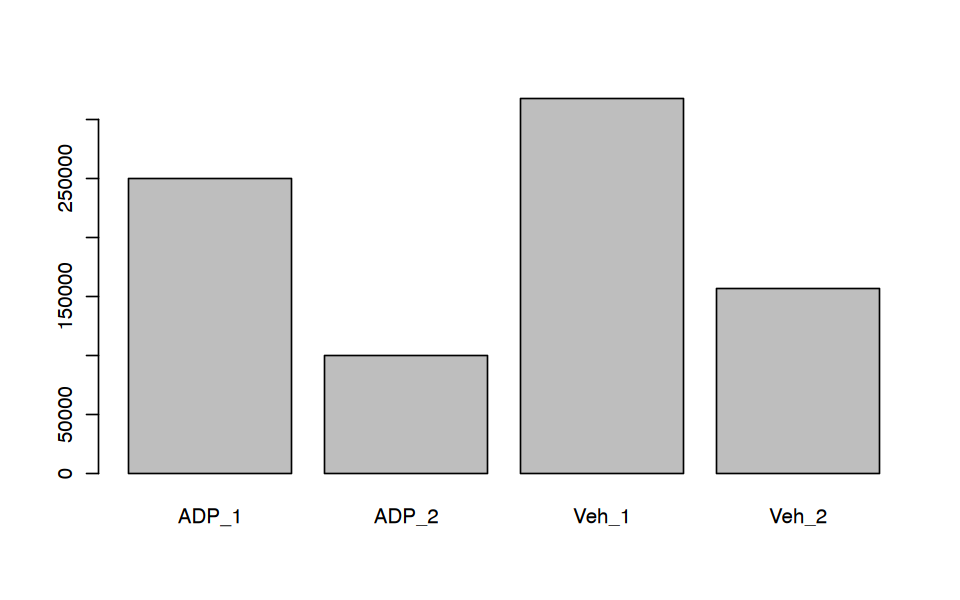

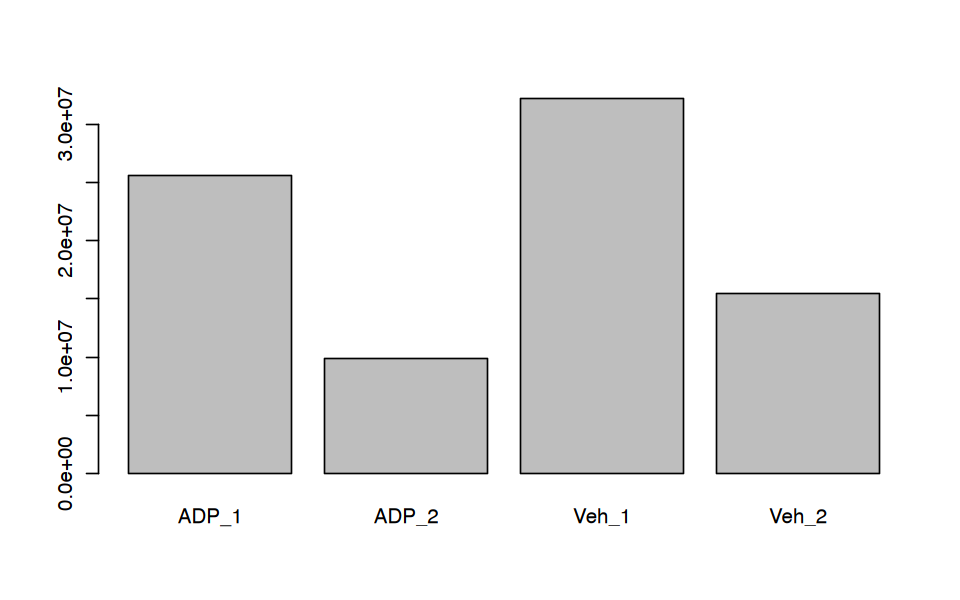

In [7]:
# check that the housekeeping genes are there
options(repr.plot.height=5, repr.plot.width=8)
hk_genes <- c(
  # Ribosomal genes (RPL and RPS families)
  "RPL3", "RPL4", "RPL5", "RPL6", "RPL7", "RPL8", "RPL9", "RPL10", "RPL10A", 
  "RPL11", "RPL12", "RPL13", "RPL13A", "RPL14", "RPL15", "RPL17", "RPL18", 
  "RPL18A", "RPL19", "RPL21", "RPL22", "RPL23", "RPL23A", "RPL24", "RPL26", 
  "RPL27", "RPL27A", "RPL28", "RPL29", "RPL30", "RPL31", "RPL32", "RPL34", 
  "RPL35", "RPL35A", "RPL36", "RPL36A", "RPL37", "RPL37A", "RPL38", "RPL39", 
  "RPS3", "RPS4X", "RPS4Y1", "RPS5", "RPS6", "RPS7", "RPS8", "RPS9", "RPS10", 
  "RPS11", "RPS12", "RPS13", "RPS14", "RPS15", "RPS15A", "RPS16", "RPS17", 
  "RPS18", "RPS19", "RPS20", "RPS21", "RPS23", "RPS24", "RPS25", "RPS26", 
  "RPS27", "RPS27A", "RPS28", "RPS29",

  # Translation factors (EEF, EIF, and GTPase families)
  "EEF1A1", "EEF1A2", "EEF1B2", "EEF1D", "EEF1G", "EEF2", "EIF1", "EIF2S1", 
  "EIF2S2", "EIF2S3", "EIF3A", "EIF3B", "EIF3C", "EIF3D", "EIF3E", "EIF3F", 
  "EIF3G", "EIF3H", "EIF3I", "EIF3J", "EIF3K", "EIF3L", "EIF3M", "EIF4A1", 
  "EIF4A2", "EIF4A3", "EIF4B", "EIF4E", "EIF4E1B", "EIF4E2", "EIF4E3", "EIF4G1", 
  "EIF4G2", "EIF4G3", "EIF5", "EIF5A", "EIF5B",

  # Transcription polymerase genes (RNA Polymerases)
  "POLR1A", "POLR1B", "POLR1C", "POLR1D", "POLR1E", "POLR2A", "POLR2B", 
  "POLR2C", "POLR2D", "POLR2E", "POLR2F", "POLR2G", "POLR2H", "POLR2I", 
  "POLR2J", "POLR2K", "POLR2L", "POLR3A", "POLR3B", "POLR3C", "POLR3D", 
  "POLR3E", "POLR3F", "POLR3G", "POLR3GL", "POLR3H"
)
length(hk_genes)
#length(intersect(gene_filt_counts$Gene, hk_genes))
gene_hk_counts <- gene_filt_counts[gene_filt_counts$Gene %in% hk_genes,]
dim(gene_hk_counts)
#gene_hk_counts
barplot(colSums(gene_hk_counts[,7:10]))
barplot(colSums(gene_counts[,7:10]))

### B. Bidirectionals

In [8]:
win_counts <- fread(paste0(count_dir, "fixed_full_bid_CUWA_ADP_3.26.25_counts.txt")) # TSS 18,017 & NonTSS 30,673

win_counts[1,]
# get easier names
colnames(win_counts) <- c("Geneid", "Chr", "Start", "End", "Strand", "Length", 
                           "ADP_1", "ADP_2", "Veh_1", "Veh_2")
# separate by tss and nontss bidirectionals
tss <- fread("/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP//data/regions/tss_bid_CUWA_3.26.25.txt")
tss[1,]
tss_win_counts <- win_counts[win_counts$Geneid %in% tss$BidID,]
nontss_win_counts <- win_counts[!win_counts$Geneid %in% tss$BidID,]
nrow(tss_win_counts)
nrow(nontss_win_counts)

Geneid,Chr,Start,End,Strand,Length,./SRR18838287.mmfilt.sorted.bam,./SRR18838288.mmfilt.sorted.bam,./SRR18838289.mmfilt.sorted.bam,./SRR18838290.mmfilt.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>
chr1:632605-632763,chr1;chr1,632426;632684,632684;633684,-;+,1260,20694,14564,19918,10385


Chr,Bid_Start,Bid_Stop,BidID,Gene_Start,Gene_Stop,TranscriptID,Strand,mu,TSS,GeneID
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
chr1,629241,629291,chr1:629230-629302,628509,629509,LOC101928626:NR_125957.1,-,629266,629009,LOC101928626


[1] 15978

[1] 55579

## Get the matrix counts

In [9]:
# for easier naming, assign matrices back to counts
tss_win_counts_matrix <- as.matrix(tss_win_counts[, 7:10])
rownames(tss_win_counts_matrix) <- tss_win_counts$Geneid
dim(tss_win_counts_matrix)
tss_win_counts <- tss_win_counts_matrix

nontss_win_counts_matrix <- as.matrix(nontss_win_counts[, 7:10])
rownames(nontss_win_counts_matrix) <- nontss_win_counts$Geneid
nontss_win_counts_matrix[1:2,]
dim(nontss_win_counts_matrix)
nontss_win_counts <- nontss_win_counts_matrix


gene_counts_matrix <- as.matrix(gene_counts[, 7:10])
rownames(gene_counts_matrix) <- gene_counts$Gene
gene_counts_matrix[1:2,]
dim(gene_counts_matrix)
gene_counts <- gene_counts_matrix

gene_filt_counts_matrix <- as.matrix(gene_filt_counts[, 7:10])
rownames(gene_filt_counts_matrix) <- gene_filt_counts$Gene
gene_filt_counts_matrix[1:2,]
dim(gene_filt_counts_matrix)
gene_filt_counts <- gene_filt_counts_matrix

gene_hk_counts <- gene_filt_counts[intersect(hk_genes, rownames(gene_filt_counts)),]
dim(gene_hk_counts)

[1] 15978     4

,ADP_1,ADP_2,Veh_1,Veh_2
chr1:785582-786076,15,4,41,9
chr1:805310-805780,13,2,17,8


[1] 55579     4

,ADP_1,ADP_2,Veh_1,Veh_2
MAP1A,0,1,4,10
H3-3B,2889,746,3304,1293


[1] 28813     4

,ADP_1,ADP_2,Veh_1,Veh_2
H3-3B,2889,746,3304,1293
GRAMD1C,195,82,629,232


[1] 17152     4

[1] 131   4

### C. FIltering Bids based on counts

0%    25%    50%    75%   100% 
     0    131    670   1753 201099

[1] 51023

[1] 28106

[1] 20072

0%   25%   50%   75%  100% 
    0    10    52   179 40968

0%  25%  50%  75% 100% 
   0   10   52  178 9978

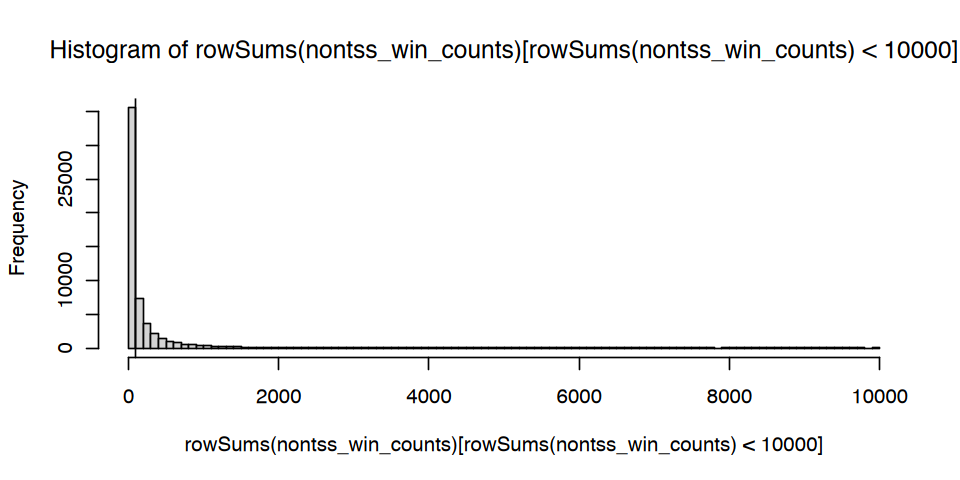

In [10]:
# exploring good cutoffs for enough transcription
quantile(rowSums(tss_win_counts))
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 0])
options(repr.plot.height=4)
hist(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) <  10000], breaks=120)
abline(v = 100)
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 50])
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 100])
quantile(rowSums(nontss_win_counts))
quantile(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) < 10000])

In [11]:
old <- nrow(tss_win_counts)
tss_win_counts_filt = tss_win_counts[rowSums(tss_win_counts) > 15,]
cat("\nFixed TSS Bid: removed",old - nrow(tss_win_counts_filt), " Bid (", 
   nrow(tss_win_counts_filt), round(nrow(tss_win_counts_filt)/old, 3)*100, "% kept)")
# NonTSS Bid
old <- nrow(nontss_win_counts)
nontss_win_counts_filt = nontss_win_counts[rowSums(nontss_win_counts) > 15,]
cat("\nFixed nonTSS Bid: removed",old - nrow(nontss_win_counts_filt), " Bid (", 
   nrow(nontss_win_counts_filt), round(nrow(nontss_win_counts_filt)/old, 3)*100, "% kept)")



Fixed TSS Bid: removed 1550  Bid ( 14428 90.3 % kept)
Fixed nonTSS Bid: removed 16621  Bid ( 38958 70.1 % kept)

## 2. Design & PCA

In [12]:
design <- data.table("Name"=c("ADP_1", "ADP_2", "Veh_1", "Veh_2"), 
                    "Replicate"=c("1", "2", "1", "2"), 
                    "Treatment"=c("ADP", "ADP", "VEH", "VEH"))
design$Replicate <- as.factor(design$Replicate)
design$Treatment <- as.factor(design$Treatment)
design


Name,Replicate,Treatment
<chr>,<fct>,<fct>
ADP_1,1,ADP
ADP_2,2,ADP
Veh_1,1,VEH
Veh_2,2,VEH


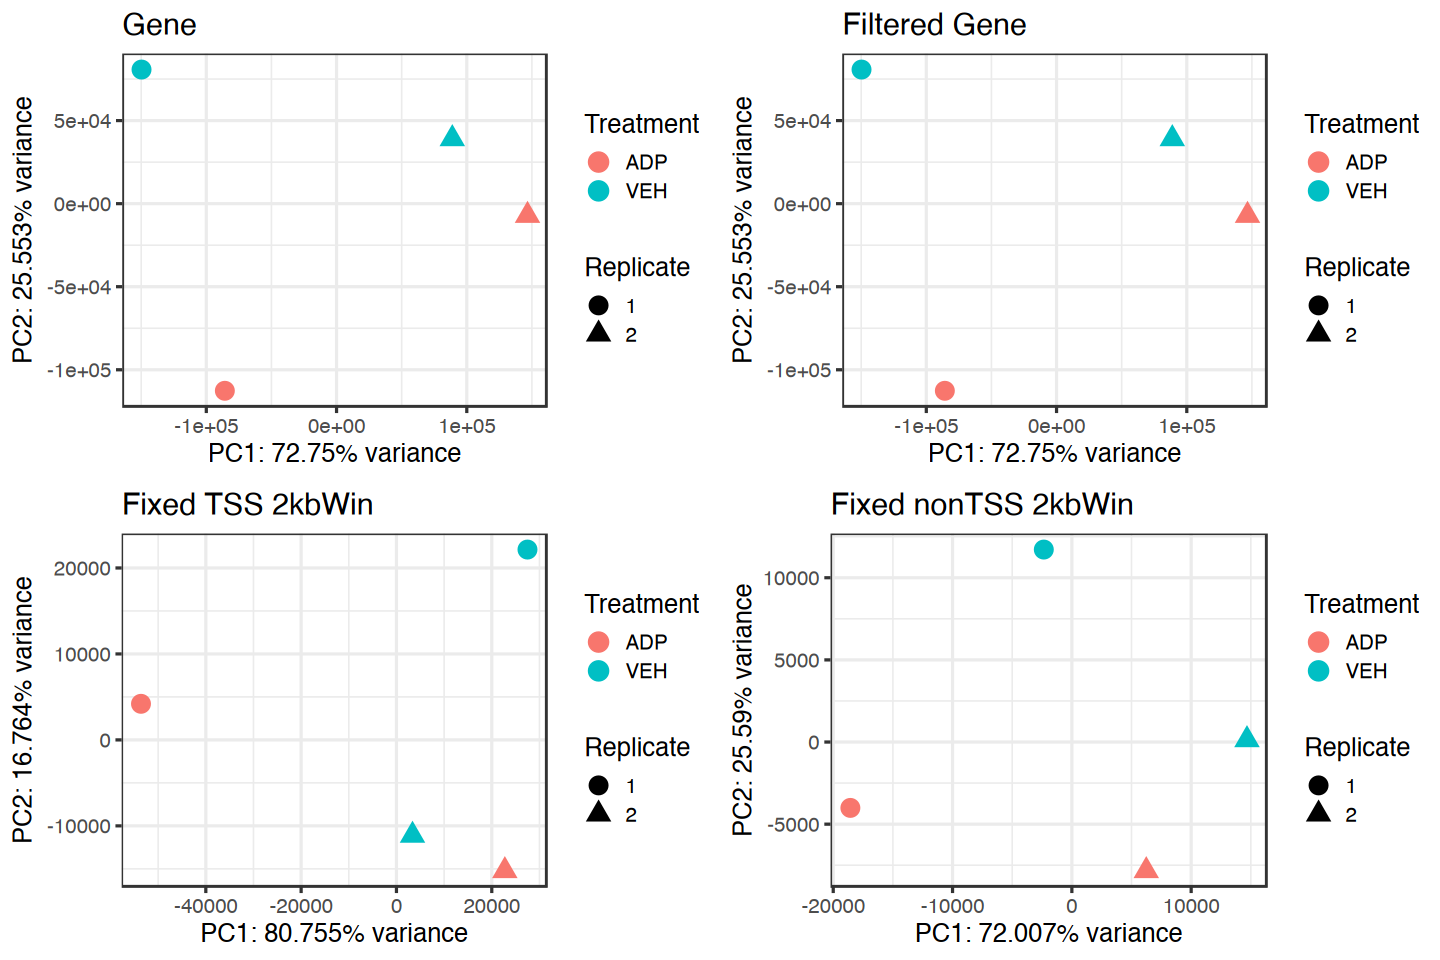

In [13]:
## Some functions for initial comparison to assess batch effects
plotPCA_hope_meta <- function(counts, metadata, ntop=500, Treat=TRUE) {
    rv <- rowVars(counts)
    length(rv) == nrow(counts)
    select <- order(rv, decreasing = TRUE)[seq_len(min(ntop,  length(rv)))]
    pca <- prcomp(t(counts[select, ]))
      percentVar <- pca$sdev^2/sum(pca$sdev^2)
    if (Treat == TRUE) {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Treatment, shape=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    } else {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    }
  
}

p4 <- plotPCA_hope_meta(gene_counts, metadata=design, ntop=500) + ggtitle(paste0("Gene"))
p5 <- plotPCA_hope_meta(gene_filt_counts, metadata=design, ntop=500) + ggtitle(paste0("Filtered Gene"))
p6 <- plotPCA_hope_meta(tss_win_counts_filt, metadata=design, ntop=500) + ggtitle(paste0("Fixed TSS 2kbWin"))
p7 <- plotPCA_hope_meta(nontss_win_counts_filt, metadata=design, ntop=500) + ggtitle(paste0("Fixed nonTSS 2kbWin"))
options(repr.plot.height = 8, repr.plot.width = 12)
plot_grid(p4, p5, p6, p7, nrow=2)

## 2. Run DESeq2

In [14]:
# get the DESeq objects
## NOT FILTERED
dds_tss_win <- DESeqDataSetFromMatrix(countData = tss_win_counts, colData = design, design = ~ Treatment)
dds_nontss_win <- DESeqDataSetFromMatrix(countData = nontss_win_counts, colData = design, design = ~ Treatment)
dds_gene <- DESeqDataSetFromMatrix(countData = gene_counts, colData = design, design = ~ Treatment)

## FILTERED
dds_gene_filt <- DESeqDataSetFromMatrix(countData = gene_filt_counts, colData = design, design = ~ Treatment)
dds_tss_win_filt <- DESeqDataSetFromMatrix(countData = tss_win_counts_filt, colData = design, design = ~ Treatment)
dds_nontss_win_filt <- DESeqDataSetFromMatrix(countData = nontss_win_counts_filt, colData = design, design = ~ Treatment)

dss_hk <- DESeqDataSetFromMatrix(countData = gene_hk_counts, colData = design, design = ~ Treatment)


In [15]:
# make clear that reference is Vehicle
dds_tss_win$Treatment <- relevel(dds_tss_win$Treatment, ref = "VEH")
dds_nontss_win$Treatment <- relevel(dds_nontss_win$Treatment, ref = "VEH")
dds_gene$Treatment <- relevel(dds_gene$Treatment, ref = "VEH")

dds_tss_win_filt$Treatment <- relevel(dds_tss_win_filt$Treatment, ref = "VEH")
dds_nontss_win_filt$Treatment <- relevel(dds_nontss_win_filt$Treatment, ref = "VEH")
dds_gene_filt$Treatment <- relevel(dds_gene_filt$Treatment, ref = "VEH")

dss_hk$Treatment <- relevel(dss_hk$Treatment, ref="VEH")

### 2A. Size Factors

[1] 133

[1] 131

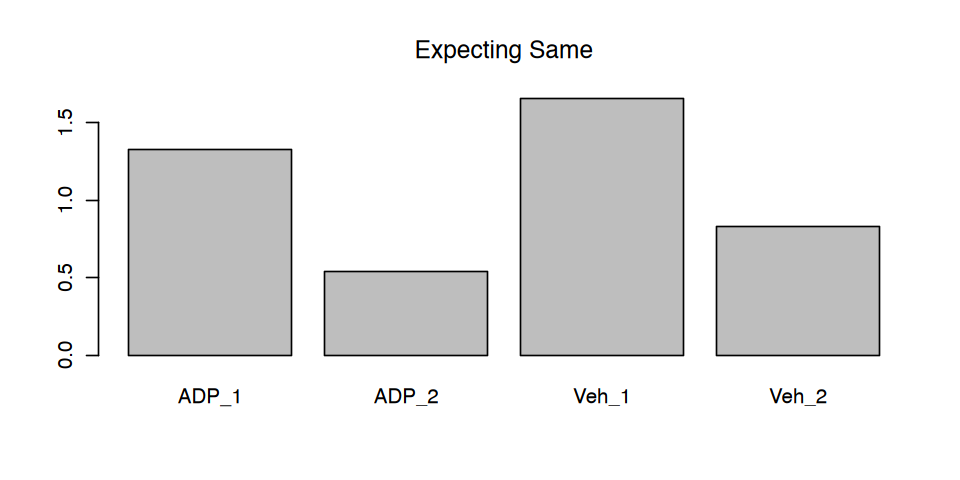

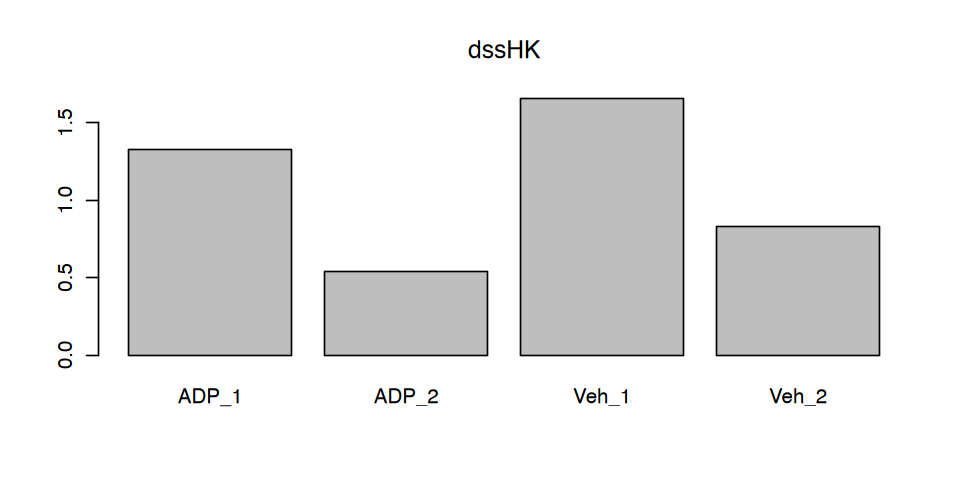

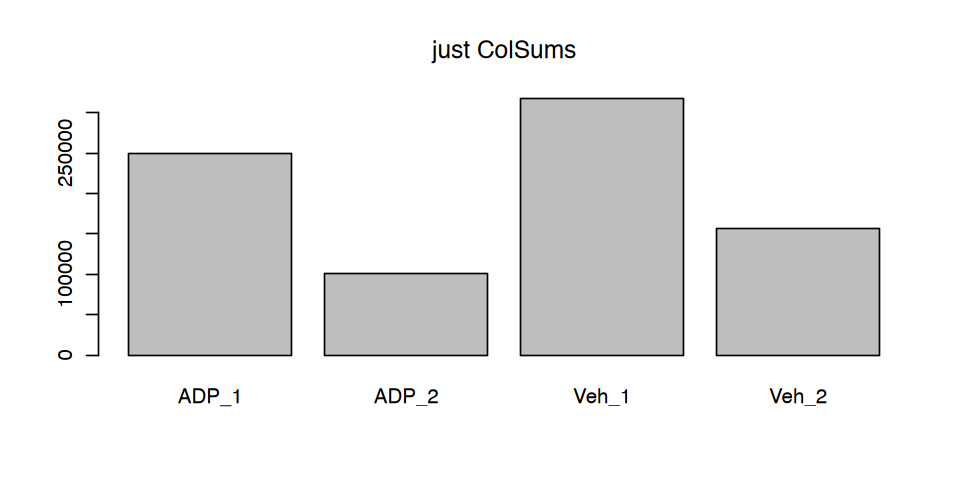

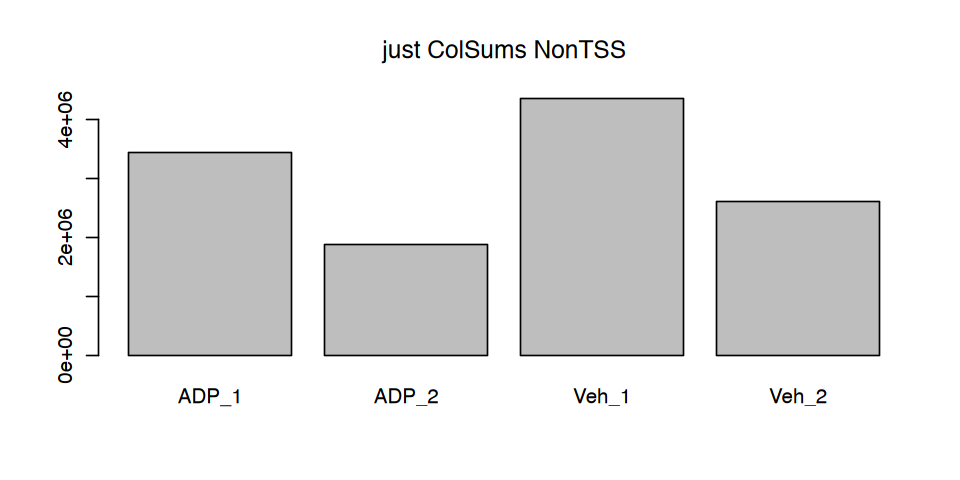

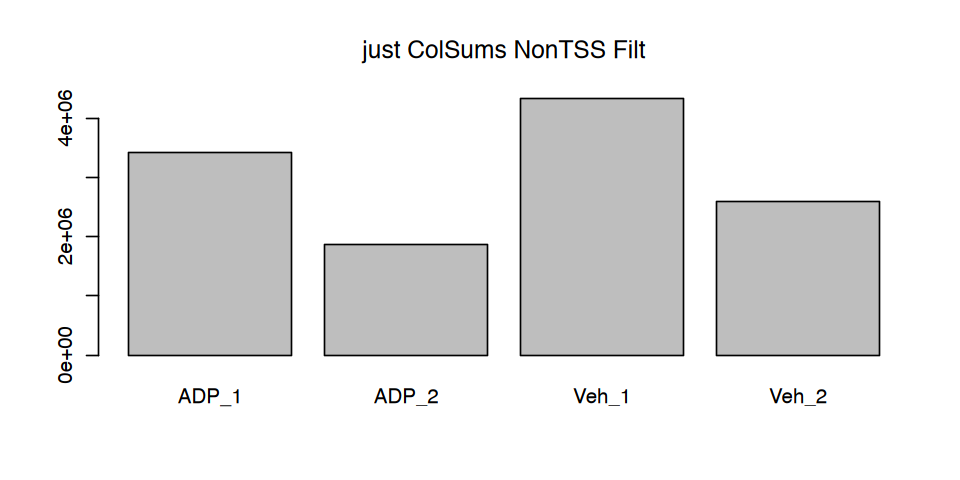

In [16]:
## Ratio
# get just the genes for normalization
isControl <- which(rownames(dds_gene_filt) %in% hk_genes)
length(hk_genes)
length(intersect(rownames(dds_gene_filt), hk_genes))
dds_gene_test = estimateSizeFactors(dds_gene_filt, controlGenes=isControl)
dds_gene_test2 = estimateSizeFactors(dss_hk)
dds_nontss_test = estimateSizeFactors(dds_nontss_win)
# test to see how different it would be without the control genes
options(repr.plot.height=4, repr.plot.width=8)
barplot(sizeFactors(dds_gene_test), main="Expecting Same")
barplot(sizeFactors(dds_gene_test2), main="dssHK")
barplot(colSums(gene_hk_counts), main="just ColSums")
barplot(colSums(nontss_win_counts), main="just ColSums NonTSS")
barplot(colSums(nontss_win_counts_filt), main="just ColSums NonTSS Filt")

In [17]:
sfs <- sizeFactors(dds_gene_test)
#sfs <- sizeFactors(dds_nontss_test)
sizeFactors(dds_tss_win) <- sfs
sizeFactors(dds_tss_win_filt) <- sfs
sizeFactors(dds_nontss_win) <- sfs
sizeFactors(dds_nontss_win_filt) <- sfs
sizeFactors(dds_gene) <- sfs
sizeFactors(dds_gene_filt) <- sfs

using ntop=500 top features by variance

using ntop=500 top features by variance

using ntop=500 top features by variance



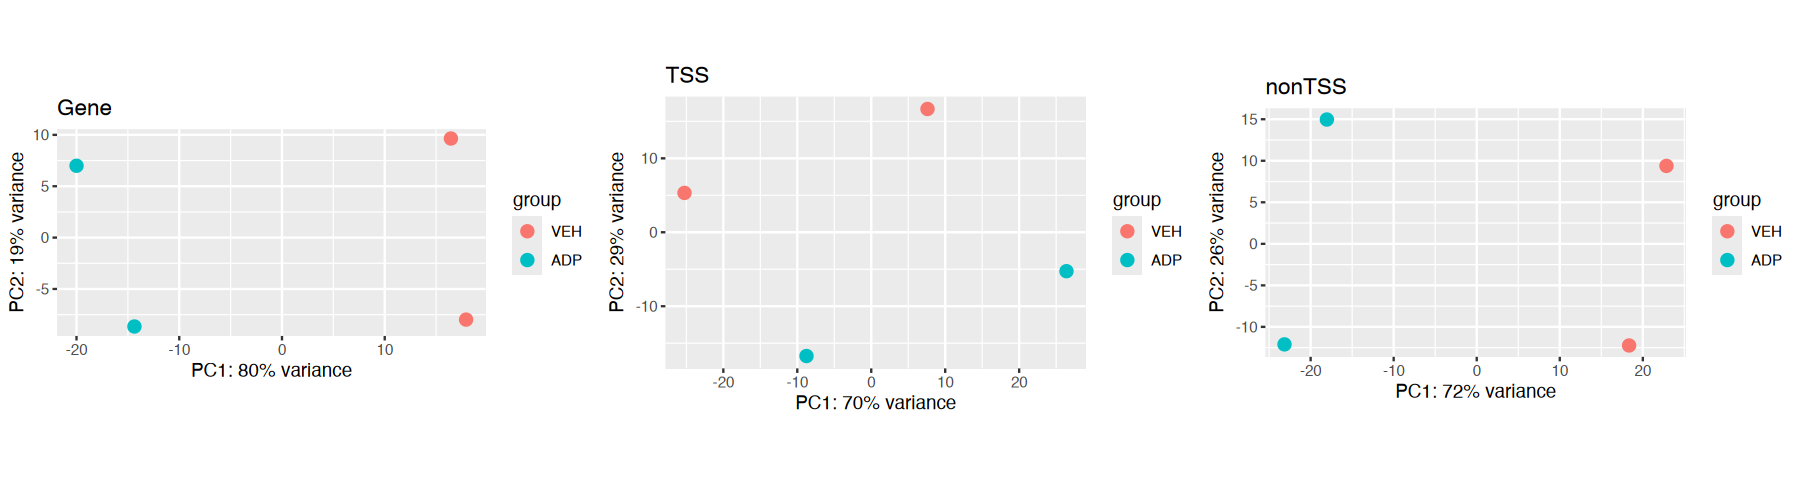

In [18]:
# plot PCA with with DESeq2 size factors
options(repr.plot.width=15, repr.plot.height=4)
# Ratio
vsd1 <- vst(dds_gene, blind = FALSE, fitType='local')
vsd3 <- vst(dds_tss_win, blind = FALSE, fitType='local')
vsd4 <- vst(dds_nontss_win, blind = FALSE, fitType='local')
p1 <- plotPCA(vsd1, intgroup = "Treatment") + ggtitle(paste0("Gene"))
p3 <- plotPCA(vsd3, intgroup = "Treatment") + ggtitle(paste0("TSS"))
p4 <- plotPCA(vsd4, intgroup = "Treatment") + ggtitle(paste0("nonTSS"))
plot_grid(p1, p3, p4, nrow=1)

### 2B. Estimate Dispersions & Run Signfiicance Tests

In [19]:
## Ratio Normalization (parameteric is default)
dds_gene = estimateDispersions(dds_gene, fitType="parametric")
dds_tss_win = estimateDispersions(dds_tss_win, fitType="parametric")
dds_nontss_win = estimateDispersions(dds_nontss_win, fitType="parametric") 

dds_gene_filt = estimateDispersions(dds_gene_filt, fitType="parametric")
dds_tss_win_filt = estimateDispersions(dds_tss_win_filt, fitType="parametric")
dds_nontss_win_filt = estimateDispersions(dds_nontss_win_filt, fitType="parametric") 

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



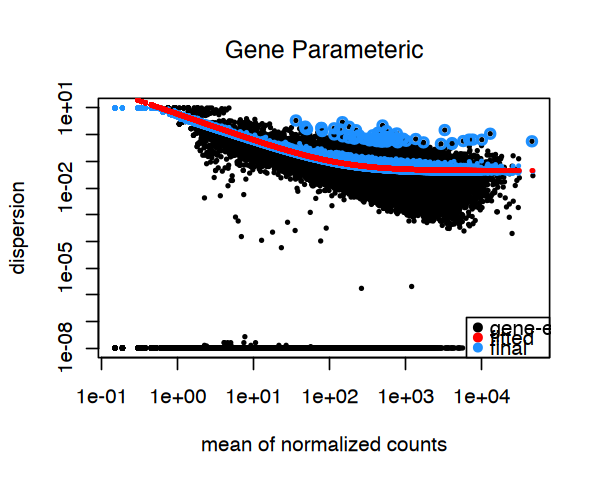

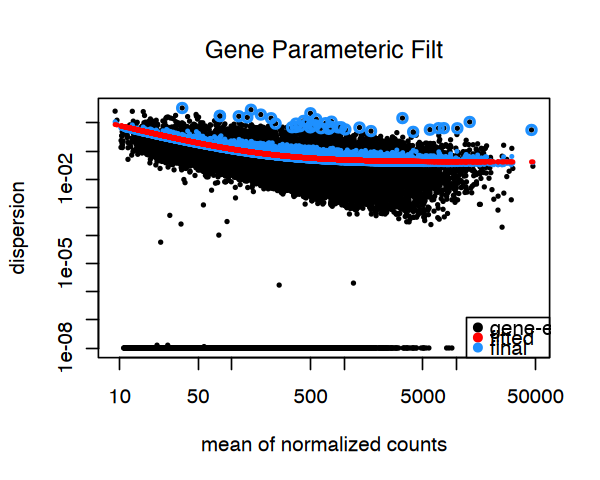

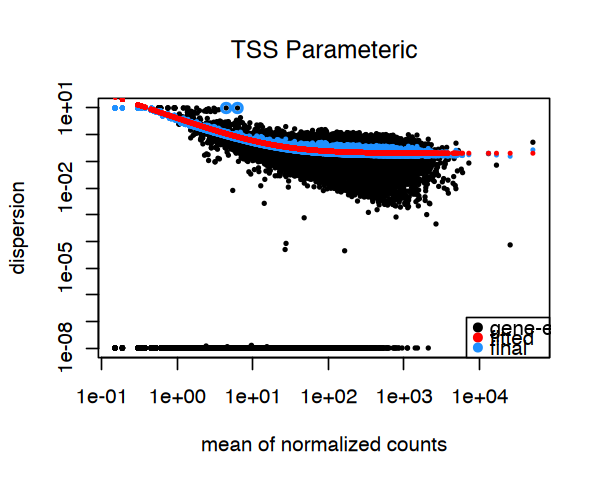

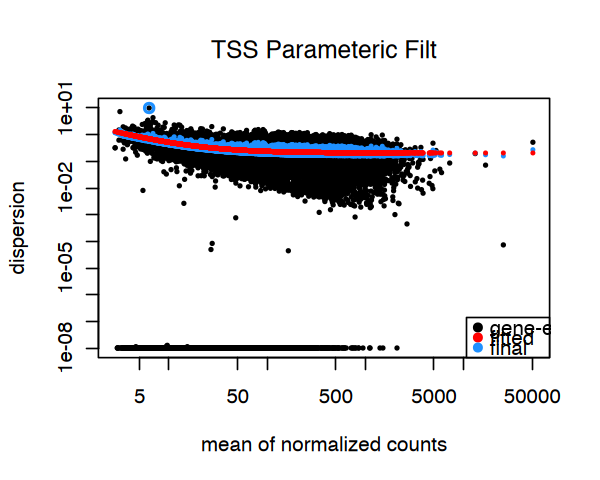

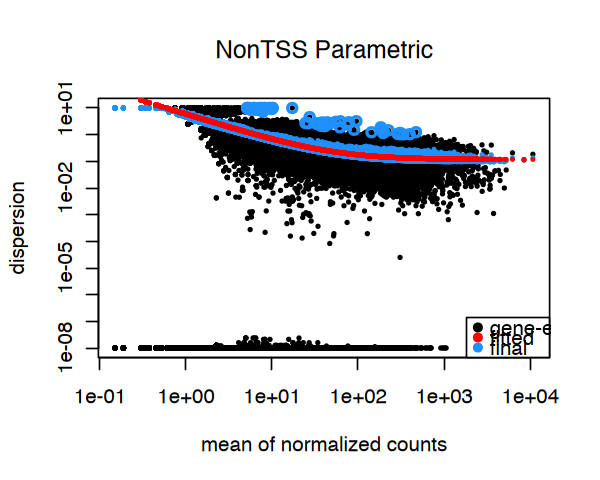

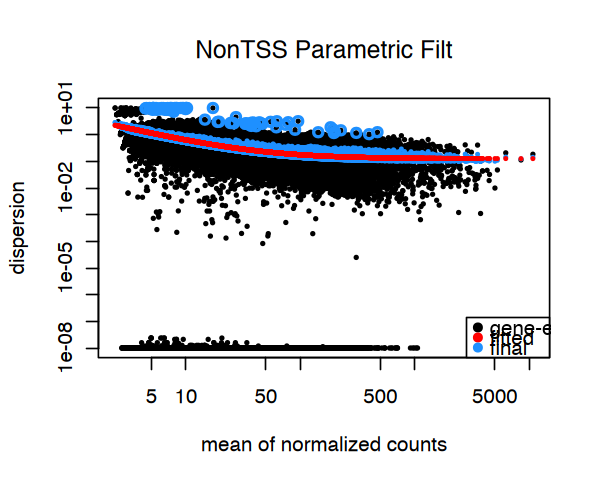

In [20]:
options(repr.plot.height=4, repr.plot.width=5)
plotDispEsts(dds_gene, main= "Gene Parameteric")
plotDispEsts(dds_gene_filt, main= "Gene Parameteric Filt")
plotDispEsts(dds_tss_win, main= "TSS Parameteric")
plotDispEsts(dds_tss_win_filt, main= "TSS Parameteric Filt")
plotDispEsts(dds_nontss_win, main= "NonTSS Parametric")
plotDispEsts(dds_nontss_win_filt, main= "NonTSS Parametric Filt")

In [21]:
dds_gene = nbinomWaldTest(dds_gene)
dds_tss_win = nbinomWaldTest(dds_tss_win)
dds_nontss_win = nbinomWaldTest(dds_nontss_win)

dds_gene_filt = nbinomWaldTest(dds_gene_filt)
dds_tss_win_filt = nbinomWaldTest(dds_tss_win_filt)
dds_nontss_win_filt = nbinomWaldTest(dds_nontss_win_filt)

In [22]:
#save normalized counts
count_df = as.data.frame(counts(dds_gene, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/ADP_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)
gc()

count_df = as.data.frame(counts(dds_nontss_win, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/ADP_nontss_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)
gc()

,ADP_1,ADP_2,Veh_1,Veh_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
MAP1A,0.000,1.851985,2.412154,12.07864,MAP1A
H3-3B,2175.825,1381.580500,1992.438995,1561.76817,H3-3B


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,7046179,376.4,12159631,649.4,NA,12159631,649.4
Vcells,23479337,179.2,40363149,308.0,16384,35240518,268.9


,ADP_1,ADP_2,Veh_1,Veh_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr1:785582-786076,11.297120,7.407938,24.72458,10.870776,chr1:785582-786076
chr1:805310-805780,9.790838,3.703969,10.25165,9.662912,chr1:805310-805780


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,7046204,376.4,12159631,649.4,NA,12159631,649.4
Vcells,23479353,179.2,40363149,308.0,16384,35240518,268.9


### 2C. Get Results

In [22]:
binwidth_use=0.05
# Set your thresholds
padj_threshold <- 0.05
log2fc_threshold <- 0

In [23]:
# Get the significance comparisons ready
Up_Sig_genes = list("P_vs_Veh"=c())
Down_Sig_genes = list("P_vs_Veh"=c())
All_Sig_genes = list("P_vs_Veh_up"=c(), "P_vs_Veh_down"=c())
Up_Sig_nontss = list("P_vs_Veh"=c())
Down_Sig_nontss = list("P_vs_Veh"=c())
All_Sig_nontss = list("P_vs_Veh_up"=c(), "P_vs_Veh_down"=c())

In [24]:
gene_tss <- as.data.frame(fread("~/Downloads/assets//hg38_TSS1kb_refseq_diff53prime_with_putatives.bed"))
gene_tss[1:2,]
# only include the calls in the counts
gene_tss = gene_tss[gene_tss$V4 %in% kept_isoforms,]
gene_tss$Gene <- str_split_fixed(gene_tss$V4, ":", 2)[,1]
# get the tss
gene_tss$tss <- as.integer(as.integer(gene_tss$V2 + gene_tss$V3)/2)
# get the start and stop of tss for 3kb window
gene_tss$start = as.integer(gene_tss$tss - 1500)
gene_tss$stop = as.integer(gene_tss$tss + 1500)

,V1,V2,V3,V4,V5,V6
,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,chr1,11373,12373,DDX11L1:NR_046018.2,.,+
2,chr1,28870,29870,WASH7P:NR_024540.1,.,-


In [33]:
# function to get TFEA results
get_tfea_input_gene <- function(res, name, gene_tss) {
    # split by fold change (0 and positive)
    # rank by p-value (FC+ highest p-value to lowest)
    res <- as.data.frame(res)
    res[1:2,]
    old <- nrow(res)
    cat("\nNum orig & new", old, nrow(res))
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
    # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    # print(pos_FC[1:2,])
    # print(neg_FC[1:2,])
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    # print the position at which the separations take place
    cat("\n Positive rank end", nrow(pos_FC), "Negative rank end", nrow(full_res)-nrow(neg_FC), "Number zeros", nrow(zero_FC))
    set_used <- rownames(full_res)
    # now get the dataframe to save
    tfea_input <- data.frame("Name"=set_used)
    print(tfea_input[1:2,])
    # fc,p-value,rank
    tfea_input$fc_info <- paste0(2**(full_res$log2FoldChange), ",", full_res$pvalue, ",", paste0(seq(1, nrow(tfea_input))))
    # get the gene tss positions to line up
    filt_tss = gene_tss[gene_tss$Gene %in% set_used,]
    rownames(filt_tss) <- filt_tss$Gene
    filt_tss = filt_tss[set_used,]
    if (!identical(filt_tss$Gene, rownames(full_res))) {
        print(filt_tss[1:2,])
        print(full_res[1:2,])
        stop("Wrong order")}
    tfea_input$chrom = filt_tss$V1
    tfea_input$start = filt_tss$start
    tfea_input$stop = filt_tss$stop
    tfea_input$gene = filt_tss$Gene
    tfea_input = tfea_input[,c("chrom", "start", "stop", "fc_info", "gene")]
    colnames(tfea_input) <- c("#chrom", "start", "stop", "fc,p-value,rank", "gene")
    print(tfea_input[1:2,])
    write.table(tfea_input, 
                paste0(tfea_input_dir, name), 
                quote=FALSE, sep="\t", row.names=FALSE)
    }

[1] "ADP vs Veh"

out of 17152 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 593, 3.5%
LFC < 0 (down)     : 654, 3.8%
outliers [1]       : 0, 0%
low counts [2]     : 333, 1.9%
(mean count < 18)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 17152 17152
 Positive rank end 6728 Negative rank end 6728 Number zeros 0[1] "TIMP2" "SPNS2"
  #chrom    start     stop                         fc,p-value,rank  gene
1  chr17 78923887 78926887 19.5909734394284,1.45699472618573e-40,1 TIMP2
2  chr17  4497380  4500380 21.2323360612102,1.11068814337312e-38,2 SPNS2


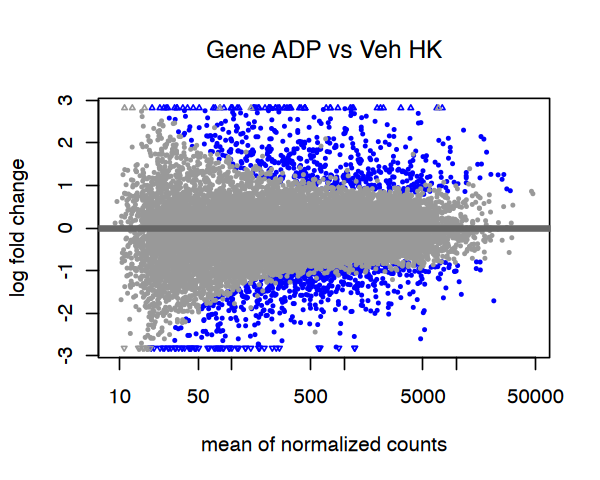

[1] 593

[1] 654

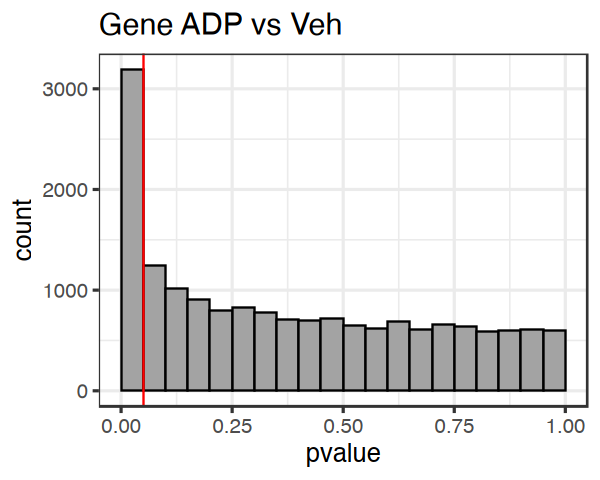

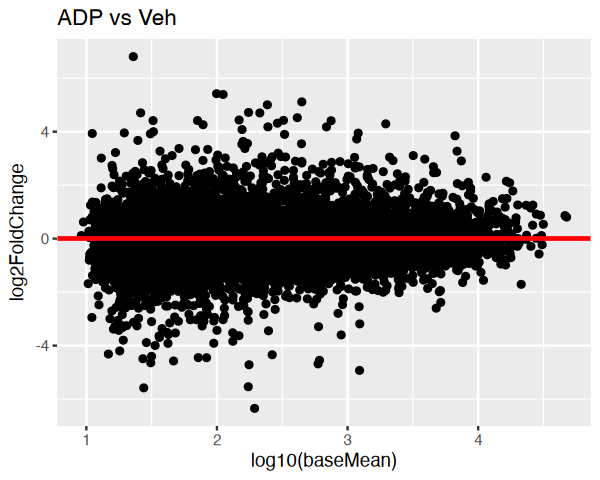

In [34]:
# Gene Results
print("ADP vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "ADP", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
get_tfea_input_gene(gene_res, "GeneTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.bed", gene_tss)
plotMA(gene_res, main="Gene ADP vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene ADP vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P_vs_Veh_down"]] = down_sig_genes
testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ADP vs Veh")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_ADP_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)




In [35]:
# function to get TFEA results
get_tfea_input <- function(res, name) {
    # split by fold change (0 and positive)
    # rank by p-value (FC+ highest p-value to lowest)
    res <- as.data.frame(res)
    res[1:2,]
    old <- nrow(res)
    cat("\nNum orig & new", old, nrow(res))
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
    # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    # print(pos_FC[1:2,])
    # print(neg_FC[1:2,])
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    # print the position at which the separations take place
    cat("\n Positive rank end", nrow(pos_FC), "Negative rank end", nrow(full_res)-nrow(neg_FC), "Number zeros", nrow(zero_FC))
    set_used <- rownames(full_res)
    # now get the dataframe to save
    tfea_input <- data.frame(str_split_fixed(set_used, ":", 2))
    print(tfea_input[1:2,])
    # fc,p-value,rank
    tfea_input$fc_info <- paste0(2**(full_res$log2FoldChange), ",", full_res$pvalue, ",", paste0(seq(1, nrow(tfea_input))))
    colnames(tfea_input) <- c("#chrom", "start_stop", "fc,p-value,rank")
    tfea_input_points = str_split_fixed(tfea_input$start_stop, "-", 2)
    tfea_input$mu <- as.integer((as.numeric(tfea_input_points[,1]) + as.numeric(tfea_input_points[,2]))/2)
    tfea_input$start = tfea_input$mu - 1500
    tfea_input$stop = tfea_input$mu + 1500
    print(tfea_input[1:2,])
    write.table(tfea_input[,c("#chrom", "start", "stop", "fc,p-value,rank")], 
                paste0(tfea_input_dir, name), 
                quote=FALSE, sep="\t", row.names=FALSE)
    }

[1] "ADP vs Veh"

out of 38958 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 448, 1.1%
LFC < 0 (down)     : 998, 2.6%
outliers [1]       : 0, 0%
low counts [2]     : 12085, 31%
(mean count < 13)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 38958 38958
 Positive rank end 16129 Negative rank end 16129 Number zeros 0     X1                X2
1  chr5 53288231-53288949
2 chr22 37545127-37545883
  #chrom        start_stop                         fc,p-value,rank       mu
1   chr5 53288231-53288949 15.2509846175619,3.41191277521443e-12,1 53288590
2  chr22 37545127-37545883 19.3815142797591,7.95651636918032e-11,2 37545505
     start     stop
1 53287090 53290090
2 37544005 37547005


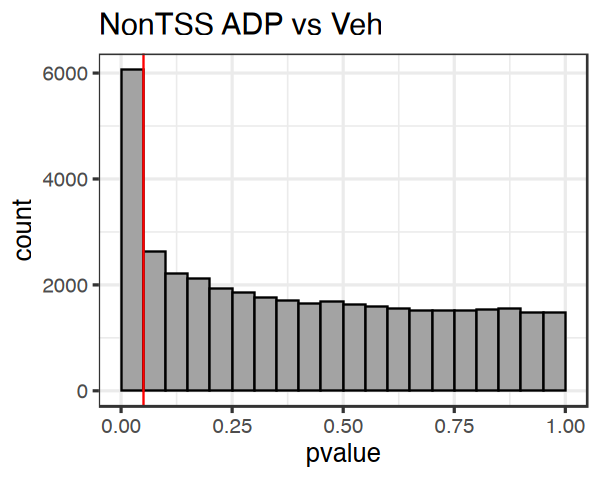

[1] 448

[1] 998

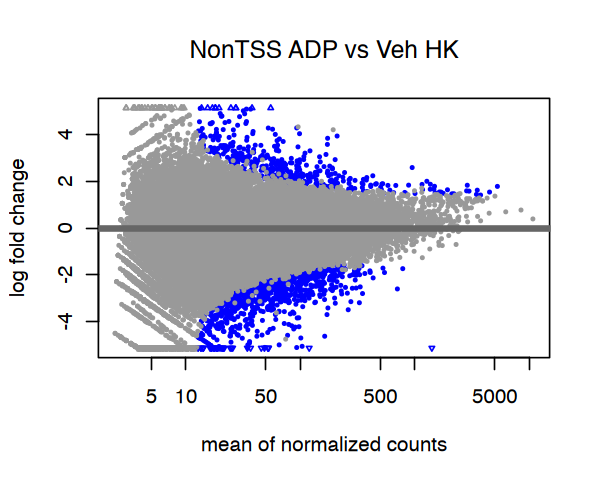

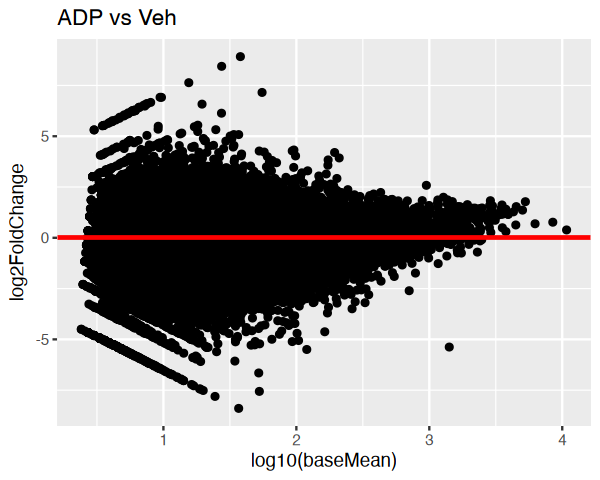

In [36]:
# NonTSS Results
options(repr.plot.height=4, repr.plot.width=5)
print("ADP vs Veh")
nontss_res = results(dds_nontss_win_filt, contrast= c("Treatment", "ADP", "VEH"), alpha=0.05)
summary(nontss_res)
get_tfea_input(nontss_res, "NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.bed")
nontss_res <- nontss_res[order(nontss_res$pvalue),]
# plot pvalues
ggplot(data.frame(nontss_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=0.05, color="red") + ggtitle("NonTSS ADP vs Veh")
plotMA(nontss_res, main="NonTSS ADP vs Veh HK")
up_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange > 0), ])
down_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange < 0), ])
length(up_sig_nontss); length(down_sig_nontss)
Up_Sig_nontss[["P_vs_Veh"]] = up_sig_nontss
All_Sig_nontss[["P_vs_Veh_up"]] = up_sig_nontss
Down_Sig_nontss[["P_vs_Veh"]] = down_sig_nontss
All_Sig_nontss[["P_vs_Veh_down"]] = down_sig_nontss
testing = as.data.frame(nontss_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("ADP vs Veh")
write.table(nontss_res, 
            paste0(results_dir, "res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)



## 4. GO Analysis with Genes

In [28]:
run_go_analysis <- function(gene_symbols) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

In [29]:
## EARLY and Temporary
length(Up_Sig_genes[["P_vs_Veh"]])
length(Down_Sig_genes[["P_vs_Veh"]])
both = union(Up_Sig_genes[["P_vs_Veh"]], Down_Sig_genes[["P_vs_Veh"]])
length(both)
go_rise = run_go_analysis(Up_Sig_genes[["P_vs_Veh"]])
go_fall = run_go_analysis(Down_Sig_genes[["P_vs_Veh"]])
go_both = run_go_analysis(both)

[1] 593

[1] 654

[1] 1247

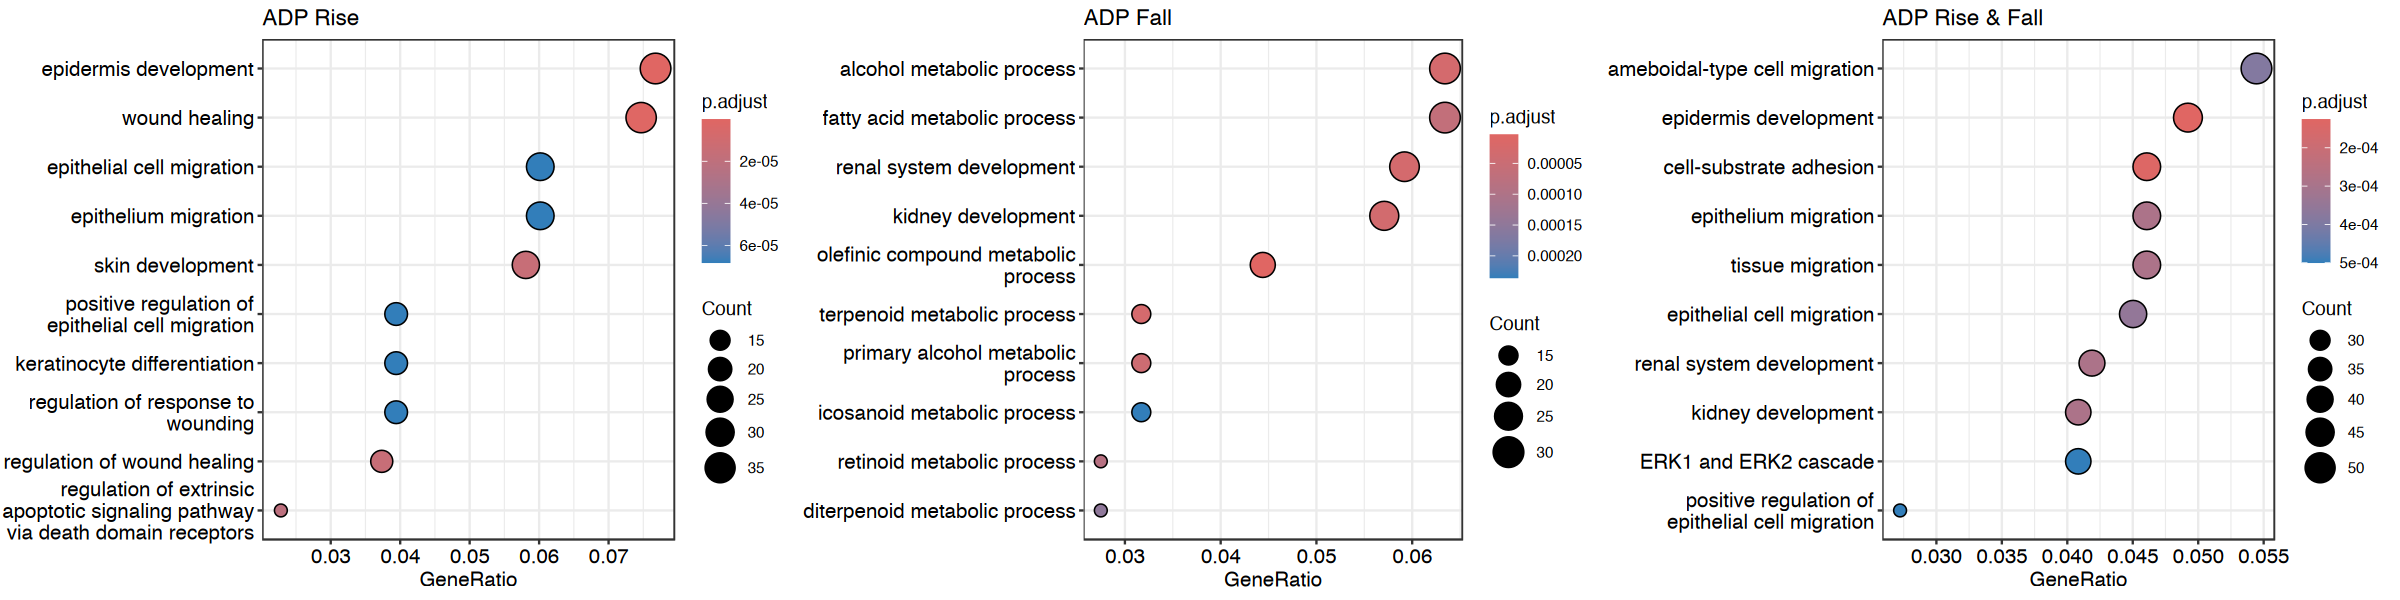

In [30]:
options(repr.plot.height=5, repr.plot.width=20)
pert="ADP"
p1 <- dotplot(go_rise, showCategory = 10, title=paste(pert,  "Rise"))
p2 <- dotplot(go_fall, showCategory = 10, title=paste(pert,  "Fall"))
p3 <- dotplot(go_both, showCategory = 10, title=paste(pert,  "Rise & Fall"))
grid.arrange(p1, p2, p3, ncol = 3)

In [39]:
write.table(go_rise, paste0("../results/GO/GO_Rise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_fall, paste0("../results/GO/GO_Fall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_both, paste0("../results/GO/GO_RiseFall", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)

In [41]:
saveRDS(All_Sig_genes, paste0(results_dir, "ADP_siggenes_DESeq2_GeneHK.rds"))
saveRDS(All_Sig_nontss, paste0(results_dir, "ADP_signontss_DESeq2_GeneHK.rds"))